In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as mticker

from utils.helper_functions import load_data
from utils.plot_functions import all_models
from utils.transfer_metrics import *

#### Load Data

In [2]:
# LOAD WORLDS
worlds_load = np.load('saved/worlds.npz')
worlds_saved = [worlds_load[f'arr_{i}'] for i in range(len(worlds_load.files))]
#worlds_saved

# LOAD REWARDS_INFO
rewards_info_load = np.load('saved/rewards_info.npz')
rewards_info = [rewards_info_load[f'arr_{i}'] for i in range(len(rewards_info_load.files))]

# Remove reward state with 0 reward per sim
reward_info_per_sim = [sim[0][sim[0][:,1] != 0] for sim in rewards_info]

# LOAD REWARDS_INFO FOR EXP2
rewards_info_load_exp2 = np.load('saved/rewards_exp2.npz')
rewards_info_exp2 = [rewards_info_load_exp2[f'arr_{i}'] for i in range(len(rewards_info_load_exp2.files))]
reward_info_per_sim_exp2 = [sim[0][sim[0][:,1] != 0] for sim in rewards_info_exp2]

# LOAD TRUE TRANSITION MATRIX FOR BASELINE, EXP2
true_tms_load = np.load('saved/true_tms_baseline.npz')
true_tms = [true_tms_load[f'arr_{i}'] for i in range(len(true_tms_load.files))]

# LOAD INIT TRANSITION MATRIX
init_tms_load = np.load('saved/init_tms.npz')
init_tms = [init_tms_load[f'arr_{i}'] for i in range(len(init_tms_load.files))]

In [ ]:
# LOAD AGENT DATA
exp = 'baseline'  # 'baseline', 'exp2', 'exp3'

# MB
mbased_expert_rewards, mbased_expert_steps, mbased_expert_value, mbased_expert_states, mbased_expert_actions, mbased_expert_model = load_data(f'saved/baseline/mbased_expert_baseline')
mbased_agent_rewards, mbased_agent_steps, mbased_agent_value, mbased_agent_states, mbased_agent_actions, mbased_agent_model = load_data(f'saved/{exp}/mbased_agent_{exp}')
mbased_vshaping_rewards, mbased_vshaping_steps, mbased_vshaping_value, mbased_vshaping_states, mbased_vshaping_actions = load_data(f'saved/{exp}/mbased_vshaping_{exp}')
mbased_dbias_rewards, mbased_dbias_steps, mbased_dbias_value, mbased_dbias_states, mbased_dbias_actions = load_data(f'saved/{exp}/mbased_dbias_{exp}')

# MF
#mfree_expert_rewards, mfree_expert_steps, mfree_expert_value, mfree_expert_states, mfree_expert_actions, _ = load_data('saved/free/expert_mfree')
mfree_agent_rewards, mfree_agent_steps, mfree_agent_value, mfree_agent_states, mfree_agent_actions, _ = load_data(f'saved/{exp}/mfree_agent_{exp}')
mfree_dbias_rewards, mfree_dbias_steps, mfree_dbias_value, mfree_dbias_states, mfree_dbias_actions = load_data(f'saved/{exp}/mfree_dbias_{exp}')
mfree_vshaping_rewards, mfree_vshaping_steps, mfree_vshaping_value, mfree_vshaping_states, mfree_vshaping_actions = load_data(f'saved/{exp}/mfree_vshaping_{exp}')

# Load tm for model-based agents
etm_load = np.load('saved/baseline/tmss/mbased_expert_tm.npz')
exp_tm = [etm_load[f'arr_{i}'] for i in range(len(etm_load.files))]

atm_load = np.load(f'saved/{exp}/tmss/mbased_agent_tm.npz')
agt_tm = [atm_load[f'arr_{i}'] for i in range(len(atm_load.files))]

vstm_load = np.load(f'saved/{exp}/tmss/vshaping_tm.npz')
vs_tm = [vstm_load[f'arr_{i}'] for i in range(len(vstm_load.files))]

dbtm_load = np.load(f'saved/{exp}/tmss/dbias_tm.npz')
db_tm = [dbtm_load[f'arr_{i}'] for i in range(len(dbtm_load.files))]

n_simulations = 1000

# true tm sumed by actions
#true_tm_load = np.load('saved/true_tm.npz')
#true_tm = [true_tm_load[f'arr_{i}'] for i in range(len(true_tm_load.files))]

# Initial tm summed by actions
#initial_tm_load = np.load('saved/initial_tm.npz')
#initial_tm = [initial_tm_load[f'arr_{i}'] for i in range(len(initial_tm_load.files))]

#### Performance

In [ ]:
## EXPERT PERFORMANCE
fig, ax = plt.subplots(figsize=(8, 5))
    
#ax.plot(sum_reward.T, linestyle='-', alpha = 0.1, color="blue")
ax.plot(np.mean(mbased_expert_rewards, axis = 0), color = "royalblue", linewidth=2, label = "Model-based Expert")
#ax.plot(np.mean(mfree_expert_rewards, axis = 0), color = "deepskyblue", linewidth=2, linestyle='--', label = "Model-free Expert" )


# Remove top and right axis
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlabel("Episodes")
ax.set_ylabel("Performance")
#ax.axvline(expert_gone,linestyle='--' , color = "black")
plt.title("Expert Comparison")
plt.legend()

#fig.savefig(f'saved/figures/performance_expert_comparison.png')

plt.show()

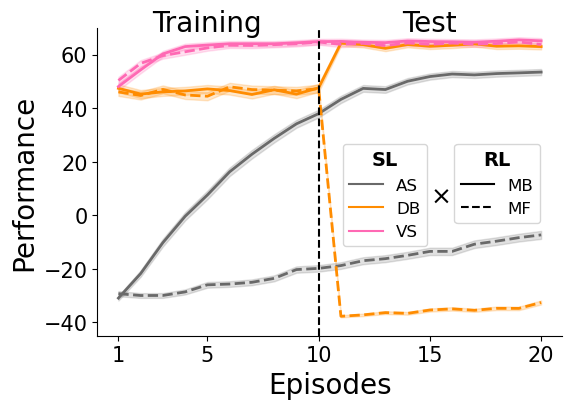

In [5]:
## ALL PERFORMANCE
mbased_performance = [mbased_agent_rewards, mbased_dbias_rewards, mbased_vshaping_rewards]
mfree_performance = [mfree_agent_rewards, mfree_dbias_rewards, mfree_vshaping_rewards]
title = exp
fig = all_models(mbased_performance, mfree_performance, 20, 0.5, title, ylabel="Performance")
# SAVE FIGURE AS SVG
#fig.savefig(f'saved/figures/{exp}/performance_{exp}.svg', bbox_inches='tight')

In [ ]:
## ALL STEPS TO REWARD
mbased_steps = [mbased_agent_steps, mbased_dbias_steps, mbased_vshaping_steps]
mfree_steps = [mfree_agent_steps, mfree_dbias_steps, mfree_vshaping_steps]
title = None
all_models(mbased_steps, mfree_steps, 20, 0.5,title, ylabel="Steps to reward" )

#### Value Transfer

##### Baseline: Compare value function of agents and expert

In [6]:
n_simulations = 1000
max_d = 5
all_states = True

# Compute the Spearman correlation coefficient
spearman_mbased_agent = value_correlation(mbased_expert_value, mbased_expert_states, mbased_agent_value, mbased_agent_states, true_tms, reward_info_per_sim, n_simulations, max_d, all_states)
spearman_mbased_dbias = value_correlation(mbased_expert_value, mbased_expert_states, mbased_dbias_value, mbased_dbias_states,true_tms, reward_info_per_sim, n_simulations, max_d, all_states)
spearman_mbased_vshaping = value_correlation(mbased_expert_value, mbased_expert_states,mbased_vshaping_value, mbased_vshaping_states,true_tms, reward_info_per_sim, n_simulations, max_d, all_states)

spearman_mfree_agent = value_correlation(mbased_expert_value, mbased_expert_states, mfree_agent_value, mfree_agent_states,true_tms, reward_info_per_sim, n_simulations, max_d, all_states)
spearman_mfree_dbias = value_correlation(mbased_expert_value, mbased_expert_states, mfree_dbias_value, mfree_dbias_states,true_tms, reward_info_per_sim, n_simulations, max_d, all_states)
spearman_mfree_vshaping = value_correlation(mbased_expert_value, mbased_expert_states,mfree_vshaping_value, mfree_vshaping_states,true_tms, reward_info_per_sim, n_simulations, max_d, all_states)

# Transform to z and back 
mean_mbased_agent, sem_mbased_agent = z_transform_intervals(spearman_mbased_agent, n_simulations)
mean_mbased_dbias, sem_mbased_dbias = z_transform_intervals(spearman_mbased_dbias, n_simulations)
mean_mbased_vshaping, sem_mbased_vshaping = z_transform_intervals(spearman_mbased_vshaping, n_simulations)

mean_mfree_agent, sem_mfree_agent = z_transform_intervals(spearman_mfree_agent, n_simulations)
mean_mfree_dbias, sem_mfree_dbias = z_transform_intervals(spearman_mfree_dbias, n_simulations)
mean_mfree_vshaping, sem_mfree_vshaping = z_transform_intervals(spearman_mfree_vshaping, n_simulations)


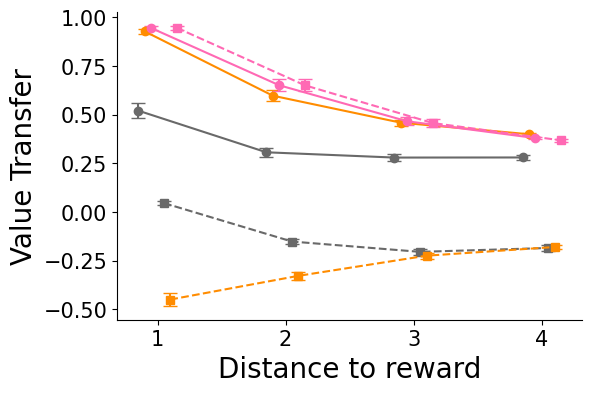

In [7]:
x = np.arange(5) 
fig, ax = plt.subplots(figsize=(6, 4))
linewidth = 1.5
offsets = [-0.15, -0.1, -0.05, 0.05, 0.1, 0.15]
x = np.arange(1, max_d)

ax.errorbar(
    x + offsets[0], mean_mbased_agent,
    yerr=sem_mbased_agent,
    fmt='o-', color="dimgray", linewidth=linewidth, label="Asocial Learning", capsize=5, capthick=1
)

ax.errorbar(
    x + offsets[1], mean_mbased_dbias,
    yerr=sem_mbased_dbias,
    fmt='o-', color="darkorange", linewidth=linewidth, label="Decision Bias", capsize=5, capthick=1
)

ax.errorbar(
    x + offsets[2], mean_mbased_vshaping,
    yerr=sem_mbased_vshaping,
    fmt='o-', color="hotpink", linewidth=linewidth, label="Value Shaping", capsize=5, capthick=1
)

ax.errorbar(
    x + offsets[3], mean_mfree_agent,
    yerr=sem_mfree_agent,
    fmt='s--', color="dimgray", linewidth=linewidth, label="Asocial Learning (MF)", capsize=5, capthick=1
)

ax.errorbar(
    x + offsets[4], mean_mfree_dbias,
    yerr=sem_mfree_dbias,
    fmt='s--', color="darkorange", linewidth=linewidth, label="Decision Bias (MF)", capsize=5, capthick=1
)

ax.errorbar(
    x + offsets[5], mean_mfree_vshaping,
    yerr=sem_mfree_vshaping,
    fmt='s--', color="hotpink", linewidth=linewidth, label="Value Shaping (MF)", capsize=5, capthick=1
)
 
# Remove top and right axis
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set x-axis ticks and labels
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels([1, 2, 3, 4], size = 15)

ax.tick_params(axis='y', labelsize=15)

ax.set_xlabel("Distance to reward", size = 20)
ax.set_ylabel("Value Transfer", size = 20)
#plt.legend()

fig.savefig(f'saved/figures/{exp}/value_correlation_{exp}.svg', bbox_inches='tight')

##### Exp. 2: Compare Value function of agents with true value function

In [ ]:
# Compute true value function using the Bellman equation
n_episodes = 20
rewards_info_test = np.array(rewards_info_exp2)[:, -n_episodes:, :] 
true_q_values = compute_true_value_function(true_tms, rewards_info_test)

In [ ]:
n_simulations = 1000
max_d = 5
all_states = False

# Compute the Spearman correlation coefficient
spearman_mbased_agent = value_correlation(true_q_values, None, mbased_agent_value, mbased_agent_states, true_tms, reward_info_per_sim, n_simulations, max_d, all_states)
spearman_mbased_dbias = value_correlation(true_q_values, None, mbased_dbias_value, mbased_dbias_states,true_tms, reward_info_per_sim, n_simulations, max_d, all_states)
spearman_mbased_vshaping = value_correlation(true_q_values, None, mbased_vshaping_value, mbased_vshaping_states, true_tms, reward_info_per_sim, n_simulations, max_d, all_states)

spearman_mfree_agent = value_correlation(true_q_values, None, mfree_agent_value, mfree_agent_states, true_tms, reward_info_per_sim, n_simulations, max_d, all_states)
spearman_mfree_dbias = value_correlation(true_q_values, None, mfree_dbias_value, mfree_dbias_states, true_tms, reward_info_per_sim, n_simulations, max_d, all_states)
spearman_mfree_vshaping = value_correlation(true_q_values, None, mfree_vshaping_value, mfree_vshaping_states, true_tms, reward_info_per_sim, n_simulations, max_d, all_states)

mean_mbased_agent, sem_mbased_agent = z_transform_intervals(spearman_mbased_agent, n_simulations)
mean_mbased_dbias, sem_mbased_dbias = z_transform_intervals(spearman_mbased_dbias, n_simulations)
mean_mbased_vshaping, sem_mbased_vshaping = z_transform_intervals(spearman_mbased_vshaping, n_simulations)

mean_mfree_agent, sem_mfree_agent = z_transform_intervals(spearman_mfree_agent, n_simulations)
mean_mfree_dbias, sem_mfree_dbias = z_transform_intervals(spearman_mfree_dbias, n_simulations)
mean_mfree_vshaping, sem_mfree_vshaping = z_transform_intervals(spearman_mfree_vshaping, n_simulations)

In [ ]:
x = np.arange(5) 
fig, ax = plt.subplots(figsize=(6, 4))

linewidth = 1.5
x = np.arange(1, max_d)

offsets = [-0.1, -0.05, 0, 0.05, 0.1, 0.15]  # Offsets for each point

ax.errorbar(
    x + offsets[0], mean_mbased_agent,
    yerr= sem_mbased_agent,
    fmt='o-', color="dimgray", linewidth=linewidth, label="Asocial Learning", capsize=5, capthick=1
)

ax.errorbar(
    x + offsets[1], mean_mbased_dbias,
    yerr= sem_mbased_dbias,
    fmt='o-', color="darkorange", linewidth=linewidth, label="Decision Bias", capsize=5, capthick=1
)

ax.errorbar(
    x, mean_mbased_vshaping,
    yerr= sem_mbased_vshaping,
    fmt='o-', color="hotpink", linewidth=linewidth, label="Value Shaping", capsize=5, capthick=1
)

ax.errorbar(
    x + offsets[3], mean_mfree_agent,
    yerr= sem_mfree_agent,  
    fmt='s--', color="dimgray", linewidth=linewidth, label="Asocial Learning (MF)", capsize=5, capthick=1
)

ax.errorbar(
    x + offsets[4], mean_mfree_dbias,
    yerr= sem_mfree_dbias,  
    fmt='s--', color="darkorange", linewidth=linewidth, label="Decision Bias (MF)", capsize=5, capthick=1
)

ax.errorbar(
    x + offsets[5], mean_mfree_vshaping,
    yerr= sem_mfree_vshaping,
    fmt='s--', color="hotpink", linewidth=linewidth, label="Value Shaping (MF)", capsize=5, capthick=1
)
 
# Remove top and right axis
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set x-axis ticks and labels
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels([1, 2, 3, 4], size = 15)

ax.tick_params(axis='y', labelsize=15)

## Custom legend
#type_of_model = [
#    Line2D([0], [0], color = "black", linewidth=1.5, label = "MB" ),
#    Line2D([0], [0], color = "black", linewidth=1.5, linestyle='--' , label = "MF"),
#    ]
#
#
#social_strategy = [
#Line2D([0], [0], color = "dimgray", linewidth=1.5, label = "AS"),
#Line2D([0], [0], color = "darkorange", linewidth=1.5, label = "DB"),
#Line2D([0], [0], color = "hotpink", linewidth=1.5, label = "VS")
#    ]
#
#legend1 = ax.legend(handles=social_strategy, loc='upper left', bbox_to_anchor=(0.38, 1), fontsize = 12, frameon=False)
#ax.add_artist(legend1)  # Add the first legend to the axes
#legend2 = ax.legend(handles=type_of_model, loc='upper left', bbox_to_anchor=(0.50, 1), fontsize = 12, frameon=False)


ax.set_xlabel("Distance to reward", size = 20)
ax.set_ylabel("Value accuracy", size = 20)
#plt.legend()

fig.savefig(f'saved/figures/{exp}/value_correlation_true_qvalues_{exp}.svg', bbox_inches='tight')
plt.show()

#### Belief Transfer

##### Baseline: Compare Expert's and Agent's Transition Matrices

In [13]:
## Correlation
max_d = 5
all_states = True
# Only for model-based
mean_mbased_agent_tm, sem_mbased_agent_tm, mean_z_mbased_agent, sem_z_mbased_agent = tm_ztransform_distance(
    exp_tm, mbased_expert_states, agt_tm, mbased_agent_states, init_tms, reward_info_per_sim, n_simulations, max_d, all_states)

mean_mbased_dbias_tm, sem_mbased_dbias_tm, mean_z_mbased_dbias, sem_z_mbased_dbias = tm_ztransform_distance(
    exp_tm, mbased_expert_states, db_tm, mbased_dbias_states, init_tms, reward_info_per_sim, n_simulations, max_d, all_states)

mean_mbased_vshaping_tm, sem_mbased_vshaping_tm, mean_z_mbased_vshaping, sem_z_mbased_vshaping = tm_ztransform_distance(
    exp_tm, mbased_expert_states, vs_tm, mbased_vshaping_states, init_tms, reward_info_per_sim, n_simulations, max_d, all_states)

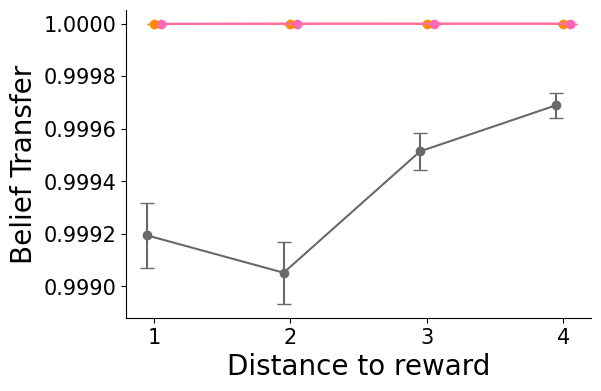

In [9]:
x = np.arange(max_d) 
fig, ax = plt.subplots(figsize=(6, 4))

offset = [-0.05, 0, 0.05] # Jitter to avoid overlap
x = np.arange(1, max_d)

ax.errorbar(
    x + offset[0], mean_mbased_agent_tm,
    yerr=sem_mbased_agent_tm,
    fmt='o-', color="dimgray", linewidth=1.5, label="Asocial Learning", capsize=5, capthick=1
)
ax.errorbar(
    x + offset[1], mean_mbased_dbias_tm,
    yerr=sem_mbased_dbias_tm,
    fmt='o-', color="darkorange", linewidth=1.5, label="Decision Bias", capsize=5, capthick=1
)
ax.errorbar(
    x + offset[2], mean_mbased_vshaping_tm,
    yerr=sem_mbased_vshaping_tm,
    fmt='o-', color="hotpink", linewidth=1.5, label="Value Shaping", capsize=5, capthick=1
)

# Remove top and right axis
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set x-axis ticks and labels
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels([1, 2, 3, 4], size = 15)

ax.tick_params(axis='y', labelsize=15)

ax.set_xlabel("Distance to reward", size = 20)
ax.set_ylabel("Belief Transfer", fontsize = 20)
#plt.legend()
fig.savefig(f'saved/figures/{exp}/tm_correlation_{exp}.svg', bbox_inches='tight')

In [11]:
## Normalized TM correlation using asocial learner as baseline --> How much "extra" belief transfer occurs?
norm_mean_dbias, norm_sem_dbias = normalize_tm_correlation(
    mean_mbased_dbias_tm, sem_mbased_dbias_tm,
    mean_mbased_agent_tm, sem_mbased_agent_tm
)

norm_mean_vshaping, norm_sem_vshaping = normalize_tm_correlation(
    mean_mbased_vshaping_tm, sem_mbased_vshaping_tm,
    mean_mbased_agent_tm, sem_mbased_agent_tm
)

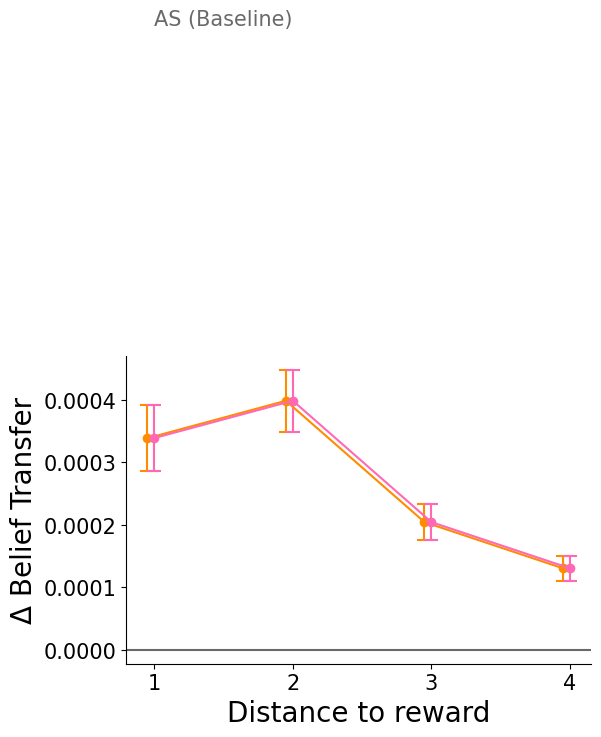

In [ ]:
x = np.arange(max_d) 
fig, ax = plt.subplots(figsize=(6, 4))

offset = [-0.05, 0, 0.05] # Jitter to avoid overlap
x = np.arange(1, max_d)


ax.errorbar(
    x + offset[0], norm_mean_dbias,
    yerr=norm_sem_dbias,
    fmt='o-', color="darkorange", linewidth=1.5, label='_nolegend_', capsize=5, capthick=1.5
)
ax.errorbar(
    x + offset[1], norm_mean_vshaping,
    yerr=norm_sem_vshaping,
    fmt='o-', color="hotpink", linewidth=1.5, label='_nolegend_', capsize=5, capthick=1.5
)
ax.axhline(0, color='dimgray', label='Baseline (AS)', linewidth=1.5)

# Remove top and right axis
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set x-axis ticks and labels
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels([1, 2, 3, 4], size = 15)

ax.tick_params(axis='y', labelsize=15)

ax.set_xlabel("Distance to reward", size = 20)
ax.set_ylabel("Δ Belief Transfer", fontsize = 20)
# Add label directly above the line
ax.text(1, 0.001, 'AS (Baseline)', color='dimgray', fontsize=15)

#fig.savefig(f'saved/figures/{exp}/tm_correlation_{exp}_baseline.svg', bbox_inches='tight')


##### Exp 3: Compare agent's TM to true TM

In [ ]:
## Correlation
max_d = 5
all_states = True
# Only for model-based
mean_mbased_agent_tm, low_mbased_agent_tm, up_mbased_agent_tm, mean_z_mbased_agent, low_z_mbased_agent, up_z_mbased_agent = tm_ztransform_distance(true_tms, None, agt_tm, mbased_agent_states, init_tms, reward_info_per_sim, n_simulations, max_d, all_states)
mean_mbased_dbias_tm, low_mbased_dbias_tm, up_mbased_dbias_tm, mean_z_mbased_dbias, low_z_mbased_dbias, up_z_mbased_dbias = tm_ztransform_distance(true_tms, None, db_tm, mbased_dbias_states, init_tms, reward_info_per_sim, n_simulations, max_d, all_states)
mean_mbased_vshaping_tm, low_mbased_vshaping_tm, up_mbased_vshaping_tm, mean_z_mbased_vshaping, low_z_mbased_vshaping, up_z_mbased_vshaping = tm_ztransform_distance(true_tms, None, vs_tm, mbased_vshaping_states, init_tms, reward_info_per_sim, n_simulations, max_d, all_states)

In [ ]:
x = np.arange(max_d) 
fig, ax = plt.subplots(figsize=(10, 5))

linewidth = 1.5
x = np.arange(1, max_d)


offset = [-0.05, 0, 0.05] # Jitter to avoid overlap

ax.errorbar(
    x + offset[0], mean_mbased_agent_tm,
    yerr=sem_mbased_agent_tm,
    fmt='o-', color="dimgray", linewidth=linewidth, label="Asocial Learning", capsize=5, capthick=1
)
ax.errorbar(
    x + offset[1], mean_mbased_dbias_tm,
    yerr=sem_mbased_dbias_tm,
    fmt='o-', color="darkorange", linewidth=linewidth, label="Decision Bias", capsize=5, capthick=1
)
ax.errorbar(
    x + offset[2], mean_mbased_vshaping_tm,
    yerr=sem_mbased_vshaping_tm,
    fmt='o-', color="hotpink", linewidth=linewidth, label="Value Shaping", capsize=5, capthick=1
)

# Remove top and right axis
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set x-axis ticks and labels
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels([1, 2, 3, 4], size = 15)

ax.tick_params(axis='y', labelsize=15)

ax.set_xlabel("Distance to reward", size = 15)
ax.set_ylabel("Belief correlation agent-ground truth", fontsize = 15)

#plt.legend()

# Save figure as SVG
fig.savefig(f'saved/figures/{exp}/tm_correlation{exp}.svg', bbox_inches='tight')

In [ ]:
## Normalized TM correlation
norm_mean_dbias, norm_sem_dbias = normalize_tm_correlation(
    mean_mbased_dbias_tm, sem_mbased_dbias_tm,
    mean_mbased_agent_tm, sem_mbased_agent_tm
)

norm_mean_vshaping, norm_sem_vshaping = normalize_tm_correlation(
    mean_mbased_vshaping_tm, sem_mbased_vshaping_tm,
    mean_mbased_agent_tm, sem_mbased_agent_tm
)

In [ ]:
x = np.arange(max_d) 
fig, ax = plt.subplots(figsize=(6, 4))

offset = [-0.05, 0, 0.05] # Jitter to avoid overlap
x = np.arange(1, max_d)

ax.errorbar(
    x + offset[0], norm_mean_dbias,
    yerr=norm_sem_dbias,
    fmt='o-', color="darkorange", linewidth=1.5, label='_nolegend_', capsize=5, capthick=1
)
ax.errorbar(
    x + offset[1], norm_mean_vshaping,
    yerr=norm_sem_vshaping,
    fmt='o-', color="hotpink", linewidth=1.5, label='_nolegend_', capsize=5, capthick=1
)
ax.axhline(0, color='dimgray', label='Baseline (AS)', linewidth=1.5)

# Remove top and right axis
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set x-axis ticks and labels
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels([1, 2, 3, 4], size = 15)

ax.tick_params(axis='y', labelsize=15)

ax.set_xlabel("Distance to reward", size = 20)
ax.set_ylabel("Δ Belief accuracy", fontsize = 20)

ax.text(1, 0.001, 'AS (Baseline)', color='dimgray', fontsize=15)

fig.savefig(f'saved/figures/{exp}/tm_correlation_{exp}_baseline.svg', bbox_inches='tight')

##### Exp3: Robustness

In [4]:
# LOAD AGENT DATA
exp = 'baseline'  # 'baseline', 'exp2', 'exp3'

# MB
mbased_expert_rewards_base, mbased_expert_steps_base, mbased_expert_value_base, mbased_expert_states_base, mbased_expert_actions_base, mbased_expert_model_base = load_data(f'saved/baseline/mbased_expert_baseline')
mbased_agent_rewards_base, mbased_agent_steps_base, mbased_agent_value_base, mbased_agent_states_base, mbased_agent_actions_base, mbased_agent_model_base = load_data(f'saved/{exp}/mbased_agent_{exp}')
mbased_vshaping_rewards_base, mbased_vshaping_steps_base, mbased_vshaping_value_base, mbased_vshaping_states_base, mbased_vshaping_actions_base = load_data(f'saved/{exp}/mbased_vshaping_{exp}')
mbased_dbias_rewards_base, mbased_dbias_steps_base, mbased_dbias_value_base, mbased_dbias_states_base, mbased_dbias_actions_base = load_data(f'saved/{exp}/mbased_dbias_{exp}')


# Load tm for model-based agents
etm_load = np.load('saved/baseline/tmss/mbased_expert_tm.npz')
exp_tm_based = [etm_load[f'arr_{i}'] for i in range(len(etm_load.files))]

atm_load = np.load(f'saved/{exp}/tmss/mbased_agent_tm.npz')
agt_tm_based = [atm_load[f'arr_{i}'] for i in range(len(atm_load.files))]

vstm_load = np.load(f'saved/{exp}/tmss/vshaping_tm.npz')
vs_tm_based = [vstm_load[f'arr_{i}'] for i in range(len(vstm_load.files))]

dbtm_load = np.load(f'saved/{exp}/tmss/dbias_tm.npz')
db_tm_based = [dbtm_load[f'arr_{i}'] for i in range(len(dbtm_load.files))]

n_simulations = 1000

In [5]:
max_d = 5
all_states = True

## Compute TM similarity over distances for new experiment and baseline
r_new_agent = tm_agent_similarity_over_distances(exp_tm, mbased_expert_states, agt_tm, mbased_agent_states, init_tms, reward_info_per_sim, n_simulations, max_d, all_states)
r_new_dbias = tm_agent_similarity_over_distances(exp_tm, mbased_expert_states, db_tm, mbased_dbias_states, init_tms, reward_info_per_sim, n_simulations, max_d, all_states)
r_new_vshaping = tm_agent_similarity_over_distances(exp_tm, mbased_expert_states, vs_tm, mbased_vshaping_states, init_tms, reward_info_per_sim, n_simulations, max_d, all_states)

r_base_agent = tm_agent_similarity_over_distances(exp_tm_based, mbased_expert_states_base, agt_tm_based, mbased_agent_states_base, init_tms, reward_info_per_sim, n_simulations, max_d, all_states)
r_base_dbias = tm_agent_similarity_over_distances(exp_tm_based, mbased_expert_states_base, db_tm_based, mbased_dbias_states_base, init_tms, reward_info_per_sim, n_simulations, max_d, all_states)
r_base_vshaping = tm_agent_similarity_over_distances(exp_tm_based, mbased_expert_states_base, vs_tm_based, mbased_vshaping_states_base, init_tms, reward_info_per_sim, n_simulations, max_d, all_states)

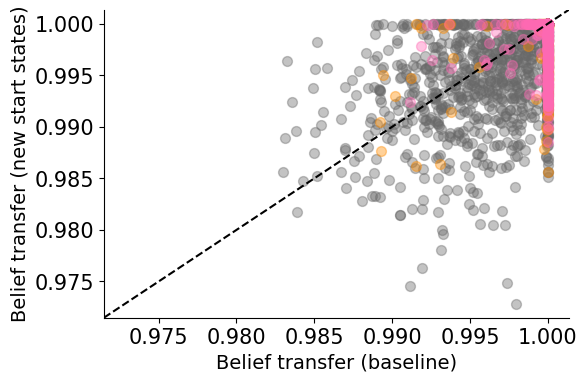

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))  # match your aspect ratio more closely

# Scatter points (same colors as your curves)
ax.scatter(
    r_base_agent, r_new_agent,
    color="dimgray", s=50, alpha=0.4, label="Asocial Learning"
)

ax.scatter(
    r_base_dbias, r_new_dbias,
    color="darkorange", s=50, alpha=0.4, label="Decision Bias"
)

ax.scatter(
    r_base_vshaping, r_new_vshaping,
    color="hotpink", s=50, alpha=0.4, label="Value Shaping"
)

# Identity line (subtle, like your errorbar lines)
lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1]),
]
ax.plot(lims, lims, linestyle="--", color="black", linewidth=1.5)
ax.set_xlim(lims)
ax.set_ylim(lims)

# Remove top and right axis (same as your other plot)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Font sizes to match your style
ax.tick_params(axis='both', labelsize=15)

ax.set_xlabel("Belief transfer (baseline)", size=14)
ax.set_ylabel("Belief transfer (new start states)", size=14)

#ax.legend(frameon=False, fontsize=13)
#fig.savefig(f'saved/figures/exp3/tm_robustness_scatter_all_agents_{exp}.svg',bbox_inches='tight')
plt.show()


In [ ]:
## Plot residuals

# Compute residuals
residual_agent = r_new_agent - r_base_agent
residual_dbias = r_new_dbias - r_base_dbias
residual_vshaping = r_new_vshaping - r_base_vshaping

# Plot histogram
fig, ax = plt.subplots(figsize=(6, 4))

bins = 15  # you can adjust

ax.hist(residual_agent, bins=bins, alpha=0.5, color='dimgray', label='Asocial Learning')
ax.hist(residual_dbias, bins=bins, alpha=0.5, color='darkorange', label='Decision Bias')
ax.hist(residual_vshaping, bins=bins, alpha=0.5, color='hotpink', label='Value Shaping')

ax.axvline(0, color='black', linestyle='--', linewidth=1.5)  # zero line

ax.set_xlabel('Residual (new states - baseline)', size=14)
ax.set_ylabel('Count', size=14)
ax.tick_params(axis='both', labelsize=13)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

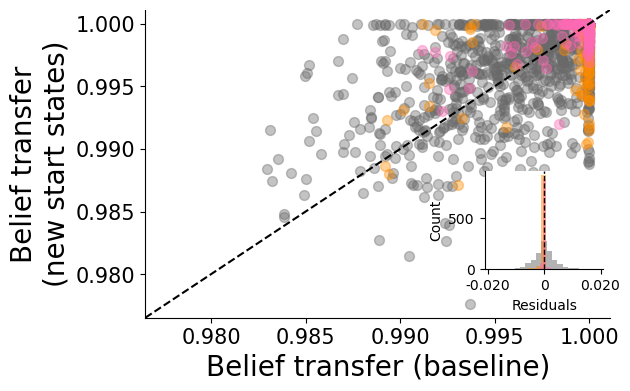

In [6]:
## Combined scatter + histogram

# --- Compute residuals ---
residual_agent = r_new_agent - r_base_agent
residual_dbias = r_new_dbias - r_base_dbias
residual_vshaping = r_new_vshaping - r_base_vshaping

# --- Main scatter plot ---
fig, ax = plt.subplots(figsize=(6, 4))

# Scatter points
ax.scatter(r_base_agent, r_new_agent,
           color="dimgray", s=50, alpha=0.4, label="Asocial Learning")
ax.scatter(r_base_dbias, r_new_dbias,
           color="darkorange", s=50, alpha=0.4, label="Decision Bias")
ax.scatter(r_base_vshaping, r_new_vshaping,
           color="hotpink", s=50, alpha=0.4, label="Value Shaping")

# Identity line
lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1]),
]
ax.plot(lims, lims, linestyle="--", color="black", linewidth=1.5)
ax.set_xlim(lims)
ax.set_ylim(lims)

# Axes style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=15)
ax.set_xlabel("Belief transfer (baseline)", size=20)
ax.set_ylabel("Belief transfer\n(new start states)", size=20)

# --- Inset histogram in bottom-right ---
axins = inset_axes(ax, width="30%", height="40%",                    
                   bbox_to_anchor=(0.15, -0.3, 0.85, 0.8),  # x0, y0, width, height in axes fraction
                   bbox_transform=ax.transAxes)

bins = 15  # number of histogram bins

axins.hist(residual_agent, bins=bins, alpha=0.5, color='dimgray', label='Asocial')
axins.hist(residual_dbias, bins=bins, alpha=0.5, color='darkorange', label='Decision Bias')
axins.hist(residual_vshaping, bins=bins, alpha=0.5, color='hotpink', label='Value Shaping')

axins.axvline(0, color='black', linestyle='--', linewidth=1)

axins.tick_params(axis='both', labelsize=10)
axins.set_xlabel('Residuals', fontsize=10)
axins.set_ylabel('Count', fontsize=10)

# Format x-axis to display 0.000 as 0
axins.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: '0' if x == 0 else f'{x:.3f}'))
axins.set_xlim(-0.021, 0.021)  # adjust x-limits as needed

# Optional: remove top/right spines in inset for style
axins.spines['top'].set_visible(False)
axins.spines['right'].set_visible(False)

# --- Show plot ---
fig.savefig(f'saved/figures/exp3/tm_robustness_scatter_histo_exp3.svg',bbox_inches='tight')
plt.show()
